# Exploration template

Use this notebook for **barebones exploratory checks** on the Kaggle Formula 1 CSVs before building a DNF model.

CSV files live in `data/` at the project root (`dsc148-f1-project/`). **Prefer starting Jupyter or the notebook kernel with the project root as the working directory.** If the kernel cwd is `notebooks/` instead, the next cell still resolves `../data` when `data/` is not found in the cwd.

In [2]:
from pathlib import Path

import pandas as pd


def resolve_data_dir() -> Path:
    for p in (Path("data"), Path("..") / "data"):
        if (p / "results.csv").exists():
            return p.resolve()
    raise FileNotFoundError(
        "Could not find data/results.csv. Place Kaggle CSVs in data/ "
        "or run Jupyter with the project root as the working directory."
    )


DATA_DIR = resolve_data_dir()
assert (DATA_DIR / "results.csv").exists(), "results.csv missing"
print(f"DATA_DIR = {DATA_DIR}")

DATA_DIR = /Users/jadengoelkel/ucsd/dsc148/dsc148-f1-project/data


## CSV inventory

In [3]:
csv_paths = sorted(DATA_DIR.glob("*.csv"))
for p in csv_paths:
    print(f"{p.name}\t{p.stat().st_size / 1024:.1f} KiB")

circuits.csv	9.9 KiB
constructor_results.csv	214.2 KiB
constructor_standings.csv	309.8 KiB
constructors.csv	17.1 KiB
driver_standings.csv	863.1 KiB
drivers.csv	92.2 KiB
lap_times.csv	17209.4 KiB
pit_stops.csv	433.3 KiB
qualifying.csv	454.3 KiB
races.csv	160.5 KiB
results.csv	1681.6 KiB
seasons.csv	4.5 KiB
sprint_results.csv	24.2 KiB
status.csv	2.1 KiB


## Core tables

In [4]:
results = pd.read_csv(DATA_DIR / "results.csv")
status = pd.read_csv(DATA_DIR / "status.csv")
races = pd.read_csv(DATA_DIR / "races.csv")
drivers = pd.read_csv(DATA_DIR / "drivers.csv")
constructors = pd.read_csv(DATA_DIR / "constructors.csv")

for name, df in [
    ("results", results),
    ("status", status),
    ("races", races),
    ("drivers", drivers),
    ("constructors", constructors),
]:
    print(f"\n=== {name} === shape {df.shape}")
    display(df.head())
    display(df.dtypes.to_frame("dtype"))


=== results === shape (26759, 18)


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1


,dtype
resultId,int64
raceId,int64
driverId,int64
constructorId,int64
number,object
grid,int64
position,object
positionText,object
positionOrder,int64
points,float64



=== status === shape (139, 2)


,statusId,status
0,1,Finished
1,2,Disqualified
2,3,Accident
3,4,Collision
4,5,Engine


...

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


,dtype
driverId,int64
driverRef,object
number,object
code,object
forename,object
surname,object
dob,object
nationality,object
url,object



=== constructors === shape (212, 5)


,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso


,dtype
constructorId,int64
constructorRef,object
name,object
nationality,object
url,object


## Results + status (DNF-oriented join)

In [15]:
results_status = results.merge(
    status, on="statusId", how="left", validate="m:1"
)
print(results_status.shape)
display(results_status.head())
display(results_status["status"].value_counts().head(20))

(26759, 19)


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,status
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,Finished
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1,Finished
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1,Finished
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1,Finished
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1,Finished


status
Finished              7674
+1 Lap                4037
Engine                2026
+2 Laps               1613
Accident              1062
Did not qualify       1025
Collision              854
Gearbox                810
Spun off               795
+3 Laps                731
Suspension             431
+4 Laps                405
Did not prequalify     331
Transmission           321
Electrical             316
Brakes                 254
Withdrew               248
+5 Laps                221
Clutch                 214
Not classified         172
Name: count, dtype: int64

## Looking if the earliest lap at which the race leader is the eventual winner at least 70% of the time decreased in Formula 1 races from 2014–2024?

In [ ]:


lap_times = pd.read_csv('../data/lap_times.csv')
races = pd.read_csv('../data/races.csv')

races = races[['raceId', 'year']]
lap_times.drop(columns=['milliseconds', 'time'], inplace=True)

df = lap_times.merge(races, on='raceId', how='left')

df.to_csv('../data/laps_and_finish_times.csv', index=False)

In [ ]:


results = []

for race_id in df['raceId'].unique():
    test = df[df['raceId'] == race_id]
    laps = test['lap'].max()

    winner = test[(test['lap'] == laps) & (test['position'] == 1)]['driverId']
    
    if winner.empty:
        continue
    
    winner_id = winner.values[0]
    df1 = test[test['driverId'] == winner_id]
    
    earliest_winning_lap = laps 
    for i in range(laps, 0, -1):
        lap_data = df1[df1['lap'] == i]['position'].values
        if len(lap_data) > 0 and lap_data[0] == 1:
            earliest_winning_lap = i
        else:
            break
    
    year = df1['year'].iloc[0]
    results.append({
        'year': year,
        'raceId': race_id,
        'winnerId': winner_id,
        'earliest_winning_lap': earliest_winning_lap,
        'total_laps': laps
    })

results_df = pd.DataFrame(results)
print(results_df)

     year  raceId  winnerId  earliest_winning_lap  total_laps
0    2011     841        20                    17          58
1    2011     842        20                    27          56
2    2011     843         1                    52          56
3    2011     844        20                    13          58
4    2011     845        20                    50          66
..    ...     ...       ...                   ...         ...
539  2024    1140       832                     9          71
540  2024    1141       830                    43          69
541  2024    1142       847                    14          50
542  2024    1143       830                     1          57
543  2024    1144       846                     1          58

[544 rows x 5 columns]


note this plot probably needs to be recreated in excel or google sheets

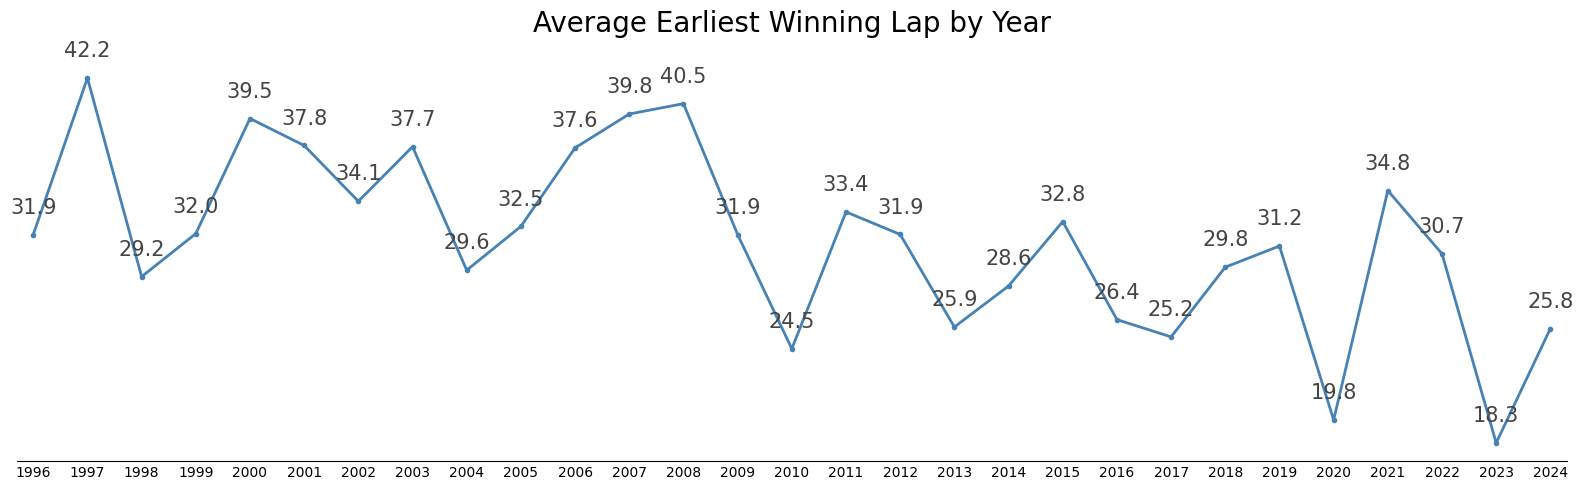

In [ ]:
import matplotlib.pyplot as plt 


res = results_df.groupby('year')['earliest_winning_lap'].mean()
fig, ax = plt.subplots(figsize=(16, 5))
res.plot(kind='line', ax=ax, marker='o', linewidth=2, markersize=3, color='steelblue')

# Labels above each point
for x, y in zip(res.index, res.values):
    ax.annotate(f'{y:.1f}', xy=(x, y), xytext=(0, 15),
                textcoords='offset points', ha='center', fontsize=15, color='#444')

ax.set_title('Average Earliest Winning Lap by Year', fontsize=20, pad=20)
ax.set_xlabel('') 
ax.set_ylabel('')
ax.set_xlim(res.index.min() - 0.3, res.index.max() + 0.3)

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.yaxis.set_visible(False)
ax.tick_params(axis='x', length=0) 
ax.grid(False)
ax.set_xticks(res.index)

plt.tight_layout()
plt.show()



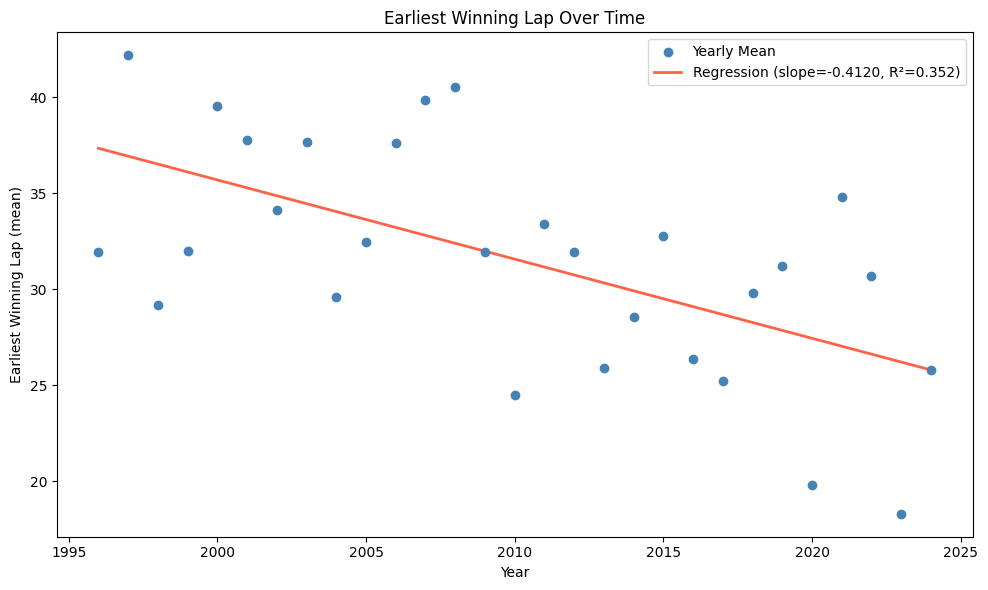

Slope:     -0.4120
Intercept: 859.6893
R²:        0.3522
P-value:   0.0007


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Compute the grouped mean
res = results_df.groupby('year')['earliest_winning_lap'].mean()

# Prepare data
x = res.index.values
y = res.values

# Fit linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
regression_line = slope * x + intercept

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(x, y, color='steelblue', zorder=5, label='Yearly Mean')
ax.plot(x, regression_line, color='tomato', linewidth=2,
        label=f'Regression (slope={slope:.4f}, R²={r_value**2:.3f})')

ax.set_xlabel('Year')
ax.set_ylabel('Earliest Winning Lap (mean)')
ax.set_title('Earliest Winning Lap Over Time')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Slope:     {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R²:        {r_value**2:.4f}")
print(f"P-value:   {p_value:.4f}")

## DNF label (foundations — target ~May 9)

**Working definition (refine as a group):** a driver result counts as a successful **finish** when `statusId == 1`, which maps to `"Finished"` in `status.csv`. Everything else is labeled **`dnf_binary = 1`** here (one not-finished bucket). That includes disqualifications, accidents, DNS, and so on. Split those into finer labels later if you move to multiclass.

Document any rule changes in your report Methods section.

In [6]:
FINISHED_STATUS_ID = 1

dnf_binary = (results_status["statusId"] != FINISHED_STATUS_ID).astype(int)
print("dnf_binary value counts:\n", dnf_binary.value_counts())
print("Overall DNF-ish rate:", dnf_binary.mean().round(4))

dnf_binary value counts:
 statusId
1    19085
0     7674
Name: count, dtype: int64
Overall DNF-ish rate: 0.7132


## Time-based train / test split

**Working split (tune with your group):** train on races with `year < TEST_YEAR_START`, test on `year >= TEST_YEAR_START`. This avoids random splits that leak future seasons into the past. Adjust the cutoff to match how much recent data you want held out.

In [7]:
races_year = pd.read_csv(DATA_DIR / "races.csv", usecols=["raceId", "year"])
labeled = results_status.merge(races_year, on="raceId", how="left", validate="m:1")

TEST_YEAR_START = 2018
train_mask = labeled["year"] < TEST_YEAR_START
test_mask = labeled["year"] >= TEST_YEAR_START

print("Train rows:", int(train_mask.sum()), "Test rows:", int(test_mask.sum()))
print("Train DNF rate:", float(dnf_binary[train_mask].mean()))
print("Test DNF rate:", float(dnf_binary[test_mask].mean()))

Train rows: 23780 Test rows: 2979
Train DNF rate: 0.7473086627417999
Test DNF rate: 0.44108761329305135
